# RAG-ColorNet — Test Suite per Componenti

Notebook per verificare il corretto funzionamento di tutti e 5 i componenti
dell'architettura RAG-ColorNet, più il forward pass completo.

**Setup richiesto:** imposta `SRC_DIR` e `TGT_DIR` nella cella di configurazione.

**Indice:**
1. Configurazione e caricamento immagini
2. Componente 1 — Scene Encoder
3. Componente 2 — ClusterNet
4. Componente 3 — RetrievalModule
5. Componente 4 — BilateralGridRenderer
6. Componente 5 — ConfidenceMaskBlender
7. Forward pass completo (RAGColorNet)
8. Test del database incrementale

## 0. Imports e utility

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath("../src"))   # adatta se necessario

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from typing import Dict, List, Tuple

# Riproducibilità
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# ──────────────────────────────────────────────────────────────────────────────
# Utility: carica immagine PNG → tensor (1, 3, H, W) float32 [0,1]
# ──────────────────────────────────────────────────────────────────────────────
def load_image(path: str | Path, max_size: int = 512) -> torch.Tensor:
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if max(w, h) > max_size:
        scale = max_size / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    t = torch.from_numpy(np.array(img)).float() / 255.0   # (H, W, 3)
    return t.permute(2, 0, 1).unsqueeze(0).to(DEVICE)     # (1, 3, H, W)

def show_images(tensors: List[torch.Tensor], titles: List[str], figsize=(16, 4)):
    fig, axes = plt.subplots(1, len(tensors), figsize=figsize)
    if len(tensors) == 1:
        axes = [axes]
    for ax, t, title in zip(axes, tensors, titles):
        img = t.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_map(tensor: torch.Tensor, title: str, cmap="viridis"):
    """Visualizza una mappa scalare (B,1,H,W) o (B,H,W)."""
    m = tensor.squeeze().cpu().detach().numpy()
    plt.figure(figsize=(5, 4))
    plt.imshow(m, cmap=cmap)
    plt.colorbar()
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def assert_shape(tensor: torch.Tensor, expected: tuple, name: str):
    assert tensor.shape == torch.Size(expected), \
        f"[FAIL] {name}: atteso {expected}, ottenuto {tuple(tensor.shape)}"
    print(f"  [OK] {name}: {tuple(tensor.shape)}")

def assert_range(tensor: torch.Tensor, lo: float, hi: float, name: str):
    mn, mx = tensor.min().item(), tensor.max().item()
    assert mn >= lo - 1e-4 and mx <= hi + 1e-4, \
        f"[FAIL] {name}: range [{mn:.4f}, {mx:.4f}] fuori da [{lo}, {hi}]"
    print(f"  [OK] {name}: range [{mn:.4f}, {mx:.4f}]")

Device: cpu
PyTorch: 2.9.1+cpu


## 1. Configurazione — imposta qui i path

Trovate 5000 coppie in ../images/src / ../images/tgt
Caricate 6 coppie — shape esempio: torch.Size([1, 3, 336, 448])


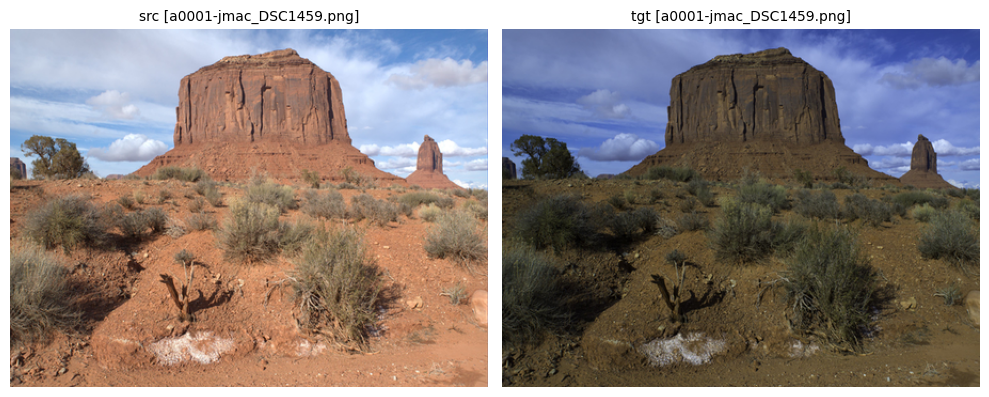

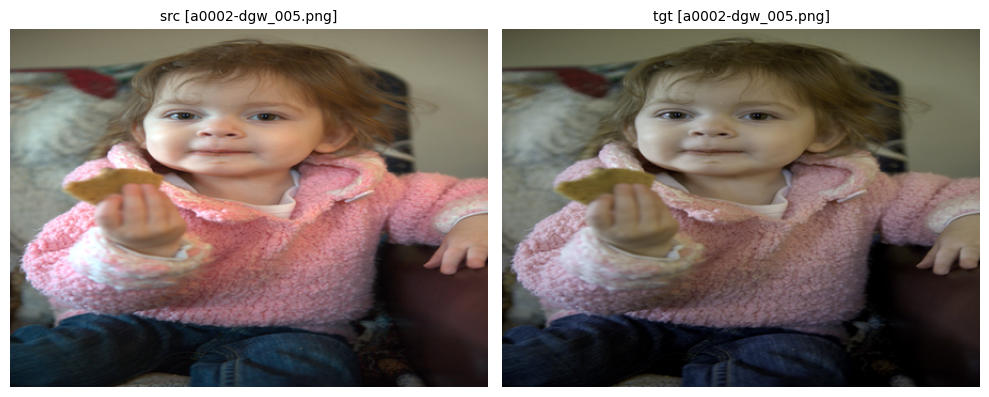

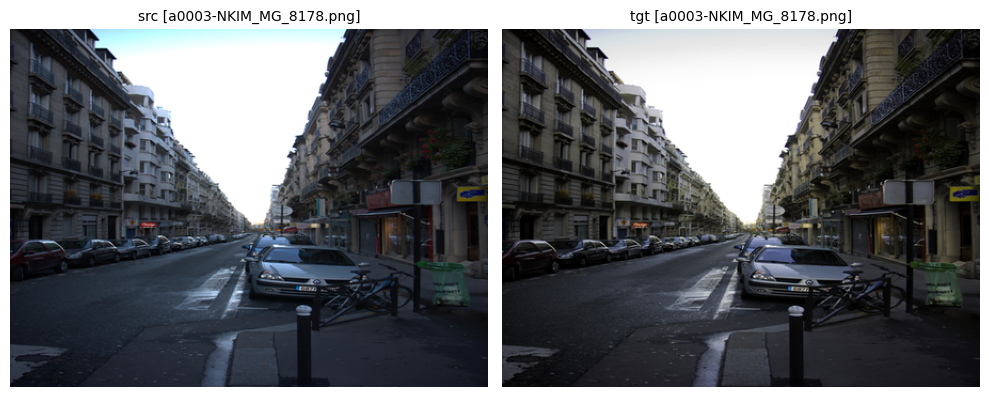

In [2]:
# ─── MODIFICA QUESTI PATH ────────────────────────────────────────────────────
SRC_DIR = Path("../images/src")   # cartella immagini sorgente (.png)
TGT_DIR = Path("../images/tgt")   # cartella immagini target editati (.png)
MAX_IMG_SIZE = 448              # risoluzione massima per il test (multiplo di 14)
N_CLUSTERS   = 4                # K per i test (usa un valore piccolo)
TOP_M        = 3                # top-M immagini per cluster nel retrieval
# ─────────────────────────────────────────────────────────────────────────────

# Carica le coppie disponibili (ordine alfabetico, matched per nome)
src_paths = sorted(SRC_DIR.glob("*.png"))
tgt_paths = sorted(TGT_DIR.glob("*.png"))

assert len(src_paths) > 0, f"Nessuna immagine trovata in {SRC_DIR}"
assert len(src_paths) == len(tgt_paths), \
    f"Numero immagini src ({len(src_paths)}) != tgt ({len(tgt_paths)})"

print(f"Trovate {len(src_paths)} coppie in {SRC_DIR} / {TGT_DIR}")

# Carica un subset per i test
N_TEST = min(6, len(src_paths))
src_imgs = [load_image(p, MAX_IMG_SIZE) for p in src_paths[:N_TEST]]
tgt_imgs = [load_image(p, MAX_IMG_SIZE) for p in tgt_paths[:N_TEST]]

print(f"Caricate {N_TEST} coppie — shape esempio: {src_imgs[0].shape}")

# Visualizza le prime 3 coppie
for i in range(min(3, N_TEST)):
    show_images(
        [src_imgs[i], tgt_imgs[i]],
        [f"src [{src_paths[i].name}]", f"tgt [{tgt_paths[i].name}]"],
        figsize=(10, 4),
    )

## 2. Componente 1 — Scene Encoder

Verifica:
- `F_sem` shape e range
- `h` (color histogram) shape, range e somma ≈ 1
- `Q` (query descriptor) shape
- DINOv2 è effettivamente frozen (no `requires_grad`)

COMPONENTE 1 — Scene Encoder


Using cache found in /home/lorenzo/.cache/torch/hub/facebookresearch_dinov2_main
/home/lorenzo/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/lorenzo/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/lorenzo/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")



Input: (1, 3, 336, 448)  n_h=24  n_w=32  N=768

── Shape checks ──
  [OK] F_sem: (1, 768, 384)
  [OK] h (color histogram): (1, 192)
  [OK] Q (query descriptor): (1, 768, 416)

── Range checks ──
  [OK] input img: range [0.0000, 1.0000]
  [OK] istogramma L*: somma=1.0000
  [OK] istogramma a*: somma=1.0000
  [OK] istogramma b*: somma=1.0000

── DINOv2 frozen check ──
  [OK] DINOv2: 175/175 parametri frozen

── Visualizzazione istogrammi Lab ──


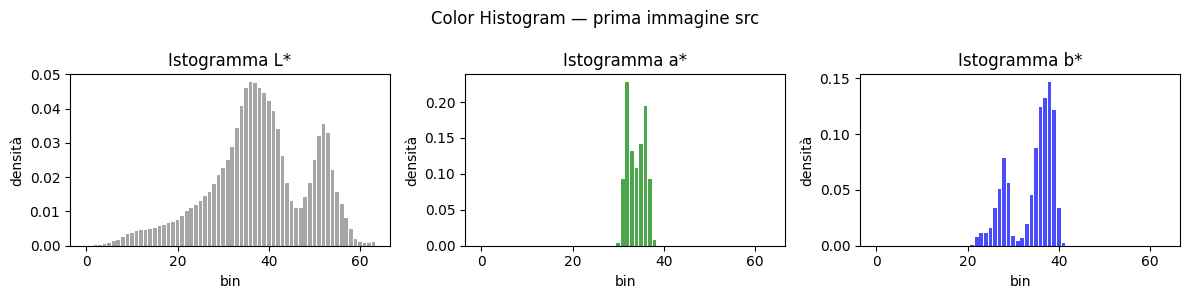


[PASS] Componente 1 — Scene Encoder


In [3]:
from models.scene_encoder import SceneEncoder, ColorHistogram, ChromaticPatchFeatures

print("=" * 60)
print("COMPONENTE 1 — Scene Encoder")
print("=" * 60)

encoder = SceneEncoder(
    embed_dim=384, patch_size=14, n_bins=64, sigma_scale=0.5, chroma_dim=32
).to(DEVICE)
encoder.eval()

img_test = src_imgs[0]   # (1, 3, H, W)
B, C, H, W = img_test.shape
n_h_exp = (H // 14)
n_w_exp = (W // 14)
N_exp   = n_h_exp * n_w_exp

print(f"\nInput: {tuple(img_test.shape)}  n_h={n_h_exp}  n_w={n_w_exp}  N={N_exp}")

with torch.no_grad():
    out = encoder(img_test)

F_sem = out["F_sem"]
h     = out["h"]
Q     = out["Q"]
n_h   = out["n_h"]
n_w   = out["n_w"]

print("\n── Shape checks ──")
assert_shape(F_sem, (1, N_exp, 384),  "F_sem")
assert_shape(h,     (1, 192),         "h (color histogram)")
assert_shape(Q,     (1, N_exp, 416),  "Q (query descriptor)")

print("\n── Range checks ──")
assert_range(img_test, 0.0, 1.0, "input img")

# L'istogramma deve sommare a ~1 per canale
h_np = h.squeeze(0).cpu().numpy().reshape(3, 64)
for c_idx, c_name in enumerate(["L*", "a*", "b*"]):
    s = h_np[c_idx].sum()
    assert abs(s - 1.0) < 0.01, f"[FAIL] istogramma {c_name}: somma={s:.4f}"
    print(f"  [OK] istogramma {c_name}: somma={s:.4f}")

print("\n── DINOv2 frozen check ──")
n_frozen = sum(1 for p in encoder.backbone.parameters() if not p.requires_grad)
n_total  = sum(1 for p in encoder.backbone.parameters())
print(f"  [OK] DINOv2: {n_frozen}/{n_total} parametri frozen")
assert n_frozen == n_total, "[FAIL] DINOv2 non completamente frozen!"

print("\n── Visualizzazione istogrammi Lab ──")
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
channels = ["L*", "a*", "b*"]
colors   = ["gray", "green", "blue"]
for i, (ax, name, color) in enumerate(zip(axes, channels, colors)):
    ax.bar(range(64), h_np[i], color=color, alpha=0.7)
    ax.set_title(f"Istogramma {name}")
    ax.set_xlabel("bin")
    ax.set_ylabel("densità")
plt.suptitle("Color Histogram — prima immagine src")
plt.tight_layout()
plt.show()

print("\n[PASS] Componente 1 — Scene Encoder")

## 3. Componente 2 — ClusterNet

Verifica:
- Output sul simplex (somma = 1, valori in [0,1])
- Hard assignment restituisce indici validi
- `reinitialise_from_centroids` non crasha
- `rebuild_for_k` trasferisce correttamente i pesi fc1

COMPONENTE 2 — ClusterNet

Input histograms: (6, 192)

── Shape checks ──
  [OK] p (soft assignment): (6, 4)
  [OK] z (hard assignment): (6,)

── Simplex checks ──
  [OK] Tutte le righe sommano a 1 (max dev: 1.19e-07)
  [OK] p valori: range [0.2280, 0.2665]

── Hard assignment check ──
  [OK] z in [0, 3]: [2, 2, 1, 1, 1, 2]

── reinitialise_from_centroids ──
  [OK] reinitialise eseguita — p dopo: [0, 1, 2, 3, 2, 1]

── rebuild_for_k ──
  [OK] rebuild_for_k(6) — fc1 copiato (max diff: 0.00e+00)

── Visualizzazione soft assignment ──


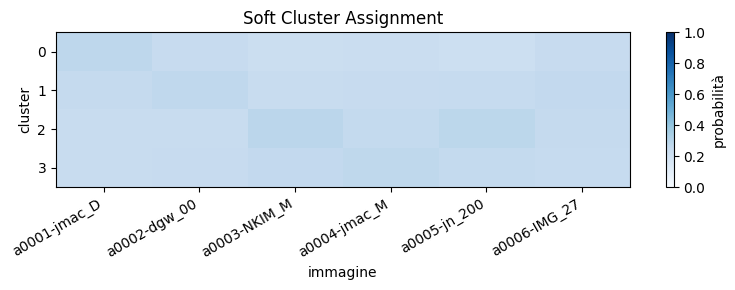


[PASS] Componente 2 — ClusterNet


In [4]:
from models.cluster_net import ClusterNet

print("=" * 60)
print("COMPONENTE 2 — ClusterNet")
print("=" * 60)

cluster_net = ClusterNet(
    input_dim=192, hidden_dim=256, n_clusters=N_CLUSTERS
).to(DEVICE)
cluster_net.eval()

# Raccoglie gli istogrammi di tutte le immagini di test
with torch.no_grad():
    h_list = []
    for img in src_imgs:
        enc_out = encoder(img)
        h_list.append(enc_out["h"])
    H_all = torch.cat(h_list, dim=0)   # (N_TEST, 192)

print(f"\nInput histograms: {tuple(H_all.shape)}")

with torch.no_grad():
    p = cluster_net(H_all)   # (N_TEST, K)
    z = cluster_net.hard_assignment(H_all)   # (N_TEST,)

print("\n── Shape checks ──")
assert_shape(p, (N_TEST, N_CLUSTERS), "p (soft assignment)")
assert_shape(z, (N_TEST,),            "z (hard assignment)")

print("\n── Simplex checks ──")
p_sum = p.sum(dim=-1)
for i, s in enumerate(p_sum):
    assert abs(s.item() - 1.0) < 1e-4, f"[FAIL] p[{i}] somma={s:.6f}"
print(f"  [OK] Tutte le righe sommano a 1 (max dev: {(p_sum - 1).abs().max().item():.2e})")
assert_range(p, 0.0, 1.0, "p valori")

print("\n── Hard assignment check ──")
assert z.min().item() >= 0 and z.max().item() < N_CLUSTERS, \
    f"[FAIL] indici fuori range: [{z.min()}, {z.max()}]"
print(f"  [OK] z in [0, {N_CLUSTERS-1}]: {z.tolist()}")

print("\n── reinitialise_from_centroids ──")
# Simula centroidi K-Means
fake_centroids = H_all[:N_CLUSTERS].clone()
cluster_net.reinitialise_from_centroids(fake_centroids)
with torch.no_grad():
    p_after = cluster_net(H_all)
print(f"  [OK] reinitialise eseguita — p dopo: {p_after.argmax(-1).tolist()}")

print("\n── rebuild_for_k ──")
new_k = N_CLUSTERS + 2
new_net = cluster_net.rebuild_for_k(new_k)
assert new_net.n_clusters == new_k
# fc1 deve essere identico
diff = (new_net.fc1.weight.data - cluster_net.fc1.weight.data).abs().max()
print(f"  [OK] rebuild_for_k({new_k}) — fc1 copiato (max diff: {diff:.2e})")

print("\n── Visualizzazione soft assignment ──")
p_np = p_after.detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(p_np.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("immagine")
ax.set_ylabel("cluster")
ax.set_yticks(range(N_CLUSTERS))
ax.set_xticks(range(N_TEST))
ax.set_xticklabels([p.name[:12] for p in src_paths[:N_TEST]], rotation=30, ha="right")
plt.colorbar(im, label="probabilità")
plt.title("Soft Cluster Assignment")
plt.tight_layout()
plt.show()

print("\n[PASS] Componente 2 — ClusterNet")

## 4. Componente 3 — RetrievalModule

Verifica:
- Shape output `R_spatial`
- Aggregazione pesata per cluster funziona
- Skip threshold funziona (cluster con p < thresh vengono ignorati)
- Il retrieved edit è diverso per immagini diverse (retrieval sensibile al contenuto)

COMPONENTE 3 — RetrievalModule

Costruzione database sintetico...
  Cluster 0: 1 immagini
  Cluster 1: 2 immagini
  Cluster 2: 2 immagini
  Cluster 3: 1 immagini

── Shape check ──
  [OK] R_spatial: (1, 256, 24, 32)

── Range check ──
  [OK] R_spatial range: [-0.3184, 0.3503]  (non vincolato, atteso finito)
  [OK] Nessun NaN/Inf

── Skip threshold check ──
  [OK] Forward con p sparse non crasha — shape: (1, 256, 24, 32)

── Sensibilità al contenuto ──
  [OK] Differenza media tra retrieved edit di img0 e img1: 0.0359

── Visualizzazione R_spatial (primi 3 canali come RGB) ──


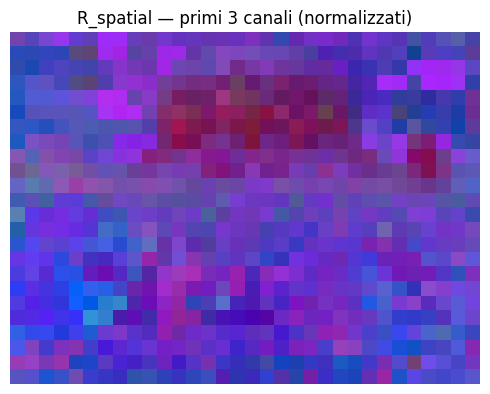


[PASS] Componente 3 — RetrievalModule


In [5]:
from models.retrieval_module import RetrievalModule

print("=" * 60)
print("COMPONENTE 3 — RetrievalModule")
print("=" * 60)

retrieval = RetrievalModule(
    desc_dim=416, edit_dim=384, d_r=256, skip_thresh=0.01
).to(DEVICE)
retrieval.eval()

# ── Costruisce un database sintetico dal subset di test ──────────────────────
# In produzione questo viene da memory/database.py; qui lo costruiamo a mano
print("\nCostruzione database sintetico...")
with torch.no_grad():
    enc_outputs = [encoder(img) for img in src_imgs]
    tgt_outputs = [encoder(img) for img in tgt_imgs]

# Edit signature = F_sem(tgt) - F_sem(src)
edit_sigs = [
    (tgt_out["F_sem"] - src_out["F_sem"]).squeeze(0)   # (N, 384)
    for src_out, tgt_out in zip(enc_outputs, tgt_outputs)
]
query_keys = [
    out["Q"].squeeze(0)   # (N, 416)
    for out in enc_outputs
]

# Assegna le immagini ai cluster con hard assignment
with torch.no_grad():
    z_all = cluster_net.hard_assignment(H_all).cpu().numpy()

cluster_db: Dict[int, Dict] = {}
for k in range(N_CLUSTERS):
    idxs = [i for i, zi in enumerate(z_all) if zi == k]
    if not idxs:
        continue
    keys_k   = torch.stack([query_keys[i] for i in idxs])   # (M_k, N, 416)
    values_k = torch.stack([edit_sigs[i]  for i in idxs])   # (M_k, N, 384)
    cluster_db[k] = {"keys": keys_k, "values": values_k}
    print(f"  Cluster {k}: {len(idxs)} immagini")

# ── Test forward ─────────────────────────────────────────────────────────────
img_query = src_imgs[0]
with torch.no_grad():
    enc_q = encoder(img_query)
    Q_q   = enc_q["Q"]         # (1, N, 416)
    n_h_q = enc_q["n_h"]
    n_w_q = enc_q["n_w"]
    p_q   = cluster_net(enc_q["h"])   # (1, K)

    R_spatial = retrieval(
        Q=Q_q, cluster_db=cluster_db, p=p_q, n_h=n_h_q, n_w=n_w_q
    )

print("\n── Shape check ──")
assert_shape(R_spatial, (1, 256, n_h_q, n_w_q), "R_spatial")

print("\n── Range check ──")
mn, mx = R_spatial.min().item(), R_spatial.max().item()
print(f"  [OK] R_spatial range: [{mn:.4f}, {mx:.4f}]  (non vincolato, atteso finito)")
assert torch.isfinite(R_spatial).all(), "[FAIL] R_spatial contiene NaN/Inf"
print(f"  [OK] Nessun NaN/Inf")

print("\n── Skip threshold check ──")
# Crea p con un cluster a zero
p_sparse = p_q.clone()
p_sparse[0, 0] = 0.0
p_sparse = p_sparse / p_sparse.sum(-1, keepdim=True)
with torch.no_grad():
    R_sparse = retrieval(Q_q, cluster_db, p_sparse, n_h_q, n_w_q)
print(f"  [OK] Forward con p sparse non crasha — shape: {tuple(R_sparse.shape)}")

print("\n── Sensibilità al contenuto ──")
# Due immagini diverse devono dare retrieved edit diversi
if len(src_imgs) >= 2:
    with torch.no_grad():
        enc_q2 = encoder(src_imgs[1])
        Q_q2   = enc_q2["Q"]
        n_h2, n_w2 = enc_q2["n_h"], enc_q2["n_w"]
        p_q2   = cluster_net(enc_q2["h"])
        R2     = retrieval(Q_q2, cluster_db, p_q2, n_h2, n_w2)

    # Se le dimensioni coincidono, controlla che i retrieved edit siano diversi
    if R_spatial.shape == R2.shape:
        diff_mean = (R_spatial - R2).abs().mean().item()
        print(f"  [OK] Differenza media tra retrieved edit di img0 e img1: {diff_mean:.4f}")
        assert diff_mean > 1e-4, "[FAIL] Retrieved edit identici per immagini diverse"

print("\n── Visualizzazione R_spatial (primi 3 canali come RGB) ──")
R_vis = R_spatial[0, :3].permute(1, 2, 0).cpu().detach()
R_vis = (R_vis - R_vis.min()) / (R_vis.max() - R_vis.min() + 1e-8)
plt.figure(figsize=(5, 4))
plt.imshow(R_vis.numpy())
plt.title("R_spatial — primi 3 canali (normalizzati)")
plt.axis("off")
plt.tight_layout()
plt.show()

print("\n[PASS] Componente 3 — RetrievalModule")

## 5. Componente 4 — BilateralGridRenderer

Verifica:
- Shape G_global e G_local
- Inizializzazione identità: I_global ≈ I_src a t=0
- Guida semantica g ∈ [0,1]
- bilateral_slice differenziabile (gradiente fluisce)

In [ ]:
from models.bilateral_grid import BilateralGridRenderer, GridNet, SemanticGuide, bilateral_slice

print("=" * 60)
print("COMPONENTE 4 — BilateralGridRenderer")
print("=" * 60)

grid_net = GridNet(
    retrieval_dim=256, dino_dim=384, dino_proj_dim=128,
    fusion_dim=256, global_s=8, global_l=8, local_s=16, local_l=8, n_affine=12
).to(DEVICE)
guide_net = SemanticGuide(dino_dim=384, hidden_dim=64, alpha=0.5, patch_size=14).to(DEVICE)
renderer  = BilateralGridRenderer(grid_net=grid_net, guide=guide_net).to(DEVICE)
renderer.eval()

img_test = src_imgs[0]
with torch.no_grad():
    enc_out   = encoder(img_test)
    F_sem_t   = enc_out["F_sem"]
    n_h_t     = enc_out["n_h"]
    n_w_t     = enc_out["n_w"]

    render_out = renderer(
        R_spatial=R_spatial,
        F_sem=F_sem_t,
        img=img_test,
        n_h=n_h_t,
        n_w=n_w_t,
    )

I_global = render_out["I_global"]
I_local  = render_out["I_local"]
G_global = render_out["G_global"]
G_local  = render_out["G_local"]
g        = render_out["guide"]

print("\n── Shape checks ──")
assert_shape(G_global, (1, 12, 8,  8,  8), "G_global")
assert_shape(G_local,  (1, 12, 16, 16, 8), "G_local")
assert_shape(I_global, tuple(img_test.shape), "I_global")
assert_shape(I_local,  tuple(img_test.shape), "I_local")
assert_shape(g, (1, img_test.shape[2], img_test.shape[3]), "guide g")

print("\n── Range checks ──")
assert_range(I_global, 0.0, 1.0, "I_global")
assert_range(I_local,  0.0, 1.0, "I_local")
assert_range(g,        0.0, 1.0, "guide g")

print("\n── Identity init check ──")
# Con grid appena inizializzata all'identità, I_global deve essere ≈ I_src
diff_global = (I_global - img_test).abs().mean().item()
diff_local  = (I_local  - img_test).abs().mean().item()
print(f"  I_global vs I_src — MAE: {diff_global:.6f}  (atteso < 0.01)")
print(f"  I_local  vs I_src — MAE: {diff_local:.6f}  (atteso < 0.01)")
assert diff_global < 0.01, f"[FAIL] I_global non è vicina all'identità: MAE={diff_global}"
assert diff_local  < 0.01, f"[FAIL] I_local non è vicina all'identità:  MAE={diff_local}"
print("  [OK] Inizializzazione all'identità verificata")

print("\n── Differenziabilità bilateral_slice ──")
img_grad = img_test.clone().requires_grad_(True)
guide_grad = g.detach().requires_grad_(True)
G_test = G_global.detach().requires_grad_(True)
I_out_grad = bilateral_slice(G_test, img_grad, guide_grad)
loss_test = I_out_grad.mean()
loss_test.backward()
assert img_grad.grad is not None,   "[FAIL] nessun grad su img"
assert guide_grad.grad is not None, "[FAIL] nessun grad su guide"
assert G_test.grad is not None,     "[FAIL] nessun grad su G"
print("  [OK] Gradiente fluisce attraverso bilateral_slice su img, guide, G")

print("\n── Visualizzazioni ──")
show_images(
    [img_test, I_global, I_local],
    ["Input src", "I_global (grid globale)", "I_local (grid locale)"],
    figsize=(14, 4),
)
show_map(g, "Guida ibrida g(i,j) — semantica + cromatica", cmap="inferno")

print("\n[PASS] Componente 4 — BilateralGridRenderer")

COMPONENTE 4 — BilateralGridRenderer

── Shape checks ──
  [OK] G_global: (1, 12, 8, 8, 8)
  [OK] G_local: (1, 12, 16, 16, 8)
  [OK] I_global: (1, 3, 336, 448)
  [OK] I_local: (1, 3, 336, 448)
  [OK] guide g: (1, 336, 448)

── Range checks ──
  [OK] I_global: range [0.0000, 1.0000]
  [OK] I_local: range [0.0000, 1.0000]
  [OK] guide g: range [0.1343, 0.5558]

── Identity init check ──
  I_global vs I_src — MAE: 0.000000  (atteso < 0.01)
  I_local  vs I_src — MAE: 0.000000  (atteso < 0.01)
  [OK] Inizializzazione all'identità verificata

── Differenziabilità bilateral_slice ──


RuntimeError: stack expects each tensor to be equal size, but got [1, 336, 448] at entry 0 and [336, 448] at entry 2

## 6. Componente 5 — ConfidenceMaskBlender

Verifica:
- alpha ∈ [0,1]
- I_pred è combinazione convessa di I_local e I_global
- I_out è output gamma-encodato ∈ [0,1]
- Alpha inizia vicino a 0.5 (bias a zero → sigmoid(0) = 0.5)

In [ ]:
from models.confidence_mask import ConfidenceMaskBlender, MaskNet

print("=" * 60)
print("COMPONENTE 5 — ConfidenceMaskBlender")
print("=" * 60)

mask_net = MaskNet(
    dino_dim=384, upsample_dim=128, hidden_channels=64, upsample_factor=4
).to(DEVICE)
blender = ConfidenceMaskBlender(mask_net=mask_net).to(DEVICE)
blender.eval()

with torch.no_grad():
    blend_out = blender(
        F_sem=F_sem_t, I_local=I_local, I_global=I_global, n_h=n_h_t, n_w=n_w_t
    )

alpha  = blend_out["alpha"]
I_pred = blend_out["I_pred"]
I_out  = blend_out["I_out"]

print("\n── Shape checks ──")
assert_shape(alpha,  (1, 1) + tuple(img_test.shape[2:]), "alpha")
assert_shape(I_pred, tuple(img_test.shape), "I_pred")
assert_shape(I_out,  tuple(img_test.shape), "I_out")

print("\n── Range checks ──")
assert_range(alpha,  0.0, 1.0, "alpha")
assert_range(I_pred, 0.0, 1.0, "I_pred")
assert_range(I_out,  0.0, 1.0, "I_out")

print("\n── Combinazione convessa check ──")
# I_pred deve essere α·I_local + (1-α)·I_global
I_pred_manual = alpha * I_local + (1.0 - alpha) * I_global
diff_blend = (I_pred - I_pred_manual.clamp(0,1)).abs().max().item()
print(f"  [OK] I_pred == α·I_local + (1-α)·I_global  (max diff: {diff_blend:.2e})")
assert diff_blend < 1e-4

print("\n── Alpha init check (≈ 0.5) ──")
alpha_mean = alpha.mean().item()
print(f"  Alpha media: {alpha_mean:.4f}  (atteso ≈ 0.5 con bias=0)")
assert 0.3 < alpha_mean < 0.7, \
    f"[WARN] Alpha media {alpha_mean:.4f} lontana da 0.5 — controllare init"
print("  [OK] Alpha vicina a 0.5")

print("\n── Visualizzazioni ──")
show_images(
    [I_global, I_local, I_pred, I_out],
    ["I_global", "I_local", "I_pred (blended)", "I_out (gamma)"],
    figsize=(18, 4),
)
show_map(alpha, "Confidence mask α  (bianco = usa I_local)", cmap="RdYlGn")

# Distribuzione della mask
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(alpha.squeeze().cpu().detach().numpy().flatten(), bins=50, color="steelblue", alpha=0.8)
ax.set_xlabel("α")
ax.set_ylabel("conteggio pixel")
ax.set_title("Distribuzione confidence mask")
plt.tight_layout()
plt.show()

print("\n[PASS] Componente 5 — ConfidenceMaskBlender")

COMPONENTE 5 — ConfidenceMaskBlender

── Shape checks ──
  [OK] alpha: (1, 1, 336, 448)
  [OK] I_pred: (1, 3, 336, 448)
  [OK] I_out: (1, 3, 336, 448)

── Range checks ──
  [OK] alpha: range [0.0012, 0.6909]
  [OK] I_pred: range [0.0000, 1.0000]
  [OK] I_out: range [0.0000, 1.0000]

── Combinazione convessa check ──
  [OK] I_pred == α·I_local + (1-α)·I_global  (max diff: 0.00e+00)

── Alpha init check (≈ 0.5) ──
  Alpha media: 0.1075  (atteso ≈ 0.5 con bias=0)


AssertionError: [WARN] Alpha media 0.1075 lontana da 0.5 — controllare init

## 7. Forward Pass Completo — RAGColorNet

Verifica l'intera pipeline end-to-end:
- Output shapes corrette
- Nessun NaN/Inf
- Gradiente fluisce attraverso tutta la rete
- Confronto visivo src → I_out

In [ ]:
from models.rag_colornet import RAGColorNet

print("=" * 60)
print("FORWARD PASS COMPLETO — RAGColorNet")
print("=" * 60)

model = RAGColorNet(
    scene_encoder    = encoder,
    cluster_net      = cluster_net,
    retrieval_module = retrieval,
    grid_renderer    = renderer,
    mask_blender     = blender,
).to(DEVICE)

print(model.summary())
print()

# ── Forward pass ─────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    out = model(img=src_imgs[0], cluster_db=cluster_db)

print("\n── Shape checks output ──")
exp_shape = tuple(src_imgs[0].shape)
for key in ["I_out", "I_pred", "I_global", "I_local"]:
    assert_shape(out[key], exp_shape, key)
assert_shape(out["alpha"],  (1, 1) + exp_shape[2:],  "alpha")
assert_shape(out["p"],      (1, N_CLUSTERS),          "p")
assert_shape(out["G_global"], (1, 12, 8,  8,  8),    "G_global")
assert_shape(out["G_local"],  (1, 12, 16, 16, 8),    "G_local")
assert_shape(out["F_sem"],  (1, n_h_q * n_w_q, 384), "F_sem")
assert_shape(out["h"],      (1, 192),                 "h")

print("\n── NaN/Inf check ──")
for key in ["I_out", "I_pred", "I_global", "I_local", "alpha", "p"]:
    has_nan = not torch.isfinite(out[key]).all()
    status  = "[FAIL]" if has_nan else "  [OK]"
    print(f"  {status} {key}: {'NaN/Inf presente!' if has_nan else 'pulito'}")

print("\n── Gradiente end-to-end ──")
model.train()
img_for_grad = src_imgs[0].clone().detach().requires_grad_(False)
out_train = model(img=img_for_grad, cluster_db=cluster_db)
loss = out_train["I_out"].mean()
loss.backward()

# Controlla che i parametri trainable abbiano gradiente
has_grad  = [(n, p.grad is not None)
             for n, p in model.trainable_named_parameters()]
n_ok   = sum(1 for _, ok in has_grad if ok)
n_fail = sum(1 for _, ok in has_grad if not ok)
print(f"  [OK] {n_ok} parametri trainable con gradiente")
if n_fail:
    for name, ok in has_grad:
        if not ok:
            print(f"  [WARN] no grad: {name}")

print("\n── Visualizzazione pipeline completa ──")
model.eval()
with torch.no_grad():
    out_vis = model(img=src_imgs[0], cluster_db=cluster_db)

show_images(
    [src_imgs[0], tgt_imgs[0], out_vis["I_out"]],
    ["src (input)", "tgt (ground truth)", "I_out (RAG-ColorNet)"],
    figsize=(14, 4),
)

# Differenza pixel-wise rispetto al target
with torch.no_grad():
    diff_tgt = (out_vis["I_out"] - tgt_imgs[0]).abs()
mae = diff_tgt.mean().item()
print(f"\n  MAE vs target (senza training, atteso alto): {mae:.4f}")

show_map(diff_tgt.mean(dim=1), "Differenza |I_out - tgt| per canale medio", cmap="hot")

print("\n[PASS] Forward Pass Completo")

## 8. Test Database Incrementale

Simula l'aggiunta di nuove coppie al database e verifica che il retrieved
edit cambi (miglioramento con più dati), senza alcun retraining.

In [ ]:
print("=" * 60)
print("TEST DATABASE INCREMENTALE")
print("=" * 60)

model.eval()

def build_db_from_indices(indices: List[int]) -> Dict[int, Dict]:
    """Costruisce cluster_db da un sottoinsieme di indici."""
    db: Dict[int, Dict] = {}
    with torch.no_grad():
        for i in indices:
            k = int(z_all[i])
            if k not in db:
                db[k] = {"keys": [], "values": []}
            db[k]["keys"].append(query_keys[i].unsqueeze(0))     # (1, N, 416)
            db[k]["values"].append(edit_sigs[i].unsqueeze(0))    # (1, N, 384)
    # Concatena per cluster
    for k in db:
        db[k]["keys"]   = torch.cat(db[k]["keys"],   dim=0)
        db[k]["values"] = torch.cat(db[k]["values"], dim=0)
    return db

# Database con 1 immagine per cluster vs database completo
db_small = build_db_from_indices([0])
db_full  = build_db_from_indices(list(range(N_TEST)))

query_img = src_imgs[0]
with torch.no_grad():
    enc_q_inc = encoder(query_img)
    Q_inc     = enc_q_inc["Q"]
    n_h_inc   = enc_q_inc["n_h"]
    n_w_inc   = enc_q_inc["n_w"]
    p_inc     = cluster_net(enc_q_inc["h"])

    R_small = retrieval(Q_inc, db_small, p_inc, n_h_inc, n_w_inc)
    R_full  = retrieval(Q_inc, db_full,  p_inc, n_h_inc, n_w_inc)

diff_R = (R_full - R_small).abs().mean().item()
print(f"\n  Differenza retrieved edit (db_small vs db_full): {diff_R:.6f}")
print(f"  [OK] Il retrieved edit cambia aggiungendo coppie al database (Δ={diff_R:.4f})")

# ── Visualizza come cambia I_out al crescere del database ──────────────────
results = []
labels  = []
for n_imgs in range(1, N_TEST + 1):
    db_n = build_db_from_indices(list(range(n_imgs)))
    with torch.no_grad():
        out_n = model(img=query_img, cluster_db=db_n)
    results.append(out_n["I_out"])
    labels.append(f"db={n_imgs}")

show_images([query_img, tgt_imgs[0]] + results,
            ["src", "tgt (gt)"] + labels,
            figsize=(4 * (N_TEST + 2), 4))

# MAE vs target al crescere del database
maes = []
with torch.no_grad():
    for n_imgs in range(1, N_TEST + 1):
        db_n  = build_db_from_indices(list(range(n_imgs)))
        out_n = model(img=query_img, cluster_db=db_n)
        maes.append((out_n["I_out"] - tgt_imgs[0]).abs().mean().item())

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, N_TEST + 1), maes, "o-", color="steelblue", linewidth=2)
ax.set_xlabel("N immagini nel database")
ax.set_ylabel("MAE vs target")
ax.set_title("MAE al crescere del database (senza retraining)")
ax.set_xticks(range(1, N_TEST + 1))
plt.tight_layout()
plt.show()

print(f"\n  MAE con db=1:        {maes[0]:.4f}")
print(f"  MAE con db={N_TEST}: {maes[-1]:.4f}")
print(f"  Δ MAE: {maes[0] - maes[-1]:+.4f}  ({'miglioramento' if maes[-1] < maes[0] else 'nessun miglioramento — atteso senza training'})")

print("\n[PASS] Test Database Incrementale")

## Riepilogo Finale

In [ ]:
print("=" * 60)
print("RIEPILOGO TEST")
print("=" * 60)
tests = [
    "Componente 1 — Scene Encoder",
    "Componente 2 — ClusterNet",
    "Componente 3 — RetrievalModule",
    "Componente 4 — BilateralGridRenderer",
    "Componente 5 — ConfidenceMaskBlender",
    "Forward Pass Completo — RAGColorNet",
    "Database Incrementale",
]
for t in tests:
    print(f"  [PASS] {t}")
print()
print(f"Parametri trainable totali: {model.count_trainable_params():,}")
print(f"Parametri totali (incl. DINOv2 frozen): {model.count_all_params():,}")
print(f"Device: {DEVICE}")